#### Classical Machine Learning for Text

- **Goal:** Establish a strong baseline. Understand how to turn text into numbers and the mechanics of classification (Weights & Gradients).
  - **Day 4-5 (Multi-class Classification):** Loading **20 Newsgroups**. Naive Bayes & Logistic Regression (Sklearn) vs. Softmax Regression (PyTorch).
- **Sources:**
  - PyTorch Linear Layer: https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html
  - PyTorch nonlinear activation: https://docs.pytorch.org/docs/main/nn.html#non-linear-activations-weighted-sum-nonlinearity
  - Sklearn models
    - linear models: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
    - Naive Bayes: https://scikit-learn.org/stable/modules/naive_bayes.html#multinomial-naive-bayes

In [1]:
# suppress warnings 
from warnings import filterwarnings
filterwarnings("ignore") 

# import the appropriate libraries
from copy import deepcopy
import torch
from torch import nn
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from utils import clean_memory, get_newsgroups_ds, create_dataloaders, plot_training_history, tune_sklearn_model

In [2]:
clean_memory()

Memory cleaned.


In [3]:
# Load data for Scikit-learn models 
seed = 204
train_df, val_df, test_df, target_names = get_newsgroups_ds(seed=seed) 

In [4]:
train_df.shape, val_df.shape, test_df.shape

((10182, 2), (1132, 2), (7532, 2))

In [5]:
target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [6]:
train_df.head()

,text,label
8540,"\nPoor Matthew. A million posters to call ""y...",0
10151,As the subject says - Can I use a 4052 for dig...,12
9146,[reply to dabbott@augean.eleceng.adelaide.edu....,13
1005,\n\nFred.\n\n\tTry reading a bit. THe governm...,14
8982,Well now that the hawks have won the division ...,10


## create features for text and make them into data loader 

In [7]:
max_features=4000
tfidf_vectorizer = TfidfVectorizer(max_features=2000)
X_train_sparse = tfidf_vectorizer.fit_transform(train_df["text"])
y_train = train_df["label"]
X_train_tensor = torch.tensor(X_train_sparse.toarray(), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_val_sparse = tfidf_vectorizer.transform(val_df["text"])
y_val = val_df["label"]
X_val_tensor = torch.tensor(X_val_sparse.toarray(), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
X_test_sparse = tfidf_vectorizer.transform(test_df["text"])
y_test = test_df["label"]
X_test_tensor = torch.tensor(X_test_sparse.toarray(), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

In [8]:
# create data loader for pytorch models
train_loader, val_loader, test_loader = create_dataloaders(X_train_tensor, y_train_tensor, 
                                                           X_val_tensor, y_val_tensor,
                                                           X_test_tensor, y_test_tensor)

### Simple multi classification model in pytorch versus linear regression multi classification
 - softmax formula
 - crossentropy loss (includes softmax) 

In [9]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
class LinearModel(nn.Module):
    def __init__(self, feature_dim, output_dim):
        super().__init__()
        self.linear_layer = nn.Linear(in_features=feature_dim, out_features=output_dim) # 20 classes, 0 to 19 

    def forward(self, X):
        return self.linear_layer(X) 

def check_early_stop(patience, val_loss, model, best_model_state, lowest_loss, counter, epoch):
    early_stop = False
    if val_loss < lowest_loss:
        lowest_loss = val_loss
        best_model_state = deepcopy(model.state_dict())
        counter = 0 
    else:
        counter += 1

    if counter >= patience:
        early_stop = True
    return best_model_state, lowest_loss, counter, early_stop

def get_correct_predictions(logits, y):
    probs = torch.softmax(logits, dim=1)
    preds = torch.argmax(probs, dim=1)
    return (preds == y).float().sum().item()

def evaluate_model(model, data_loader, criterion, device) -> tuple:
    if len(data_loader) <= 0: return 0.0, 0.0
    model.eval()
    total_size = len(data_loader.dataset)
    avg_loss = 0 
    accuracy = 0 
    # eval disables dropout/batchnorm behavior; no_grad saves memory and skips gradient computation
    with torch.no_grad():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            logit = model(x)
            loss = criterion(logit, y)
            avg_loss += loss.item()
            accuracy += get_correct_predictions(logit, y)
    avg_loss/=len(data_loader)
    accuracy/=total_size
    return avg_loss, accuracy

def train_test_model(device, model, criterion, train_loader, val_loader, patience, num_epochs, lr, l2):
    model.to(device)
    optimizer = torch.optim.Adam(params=model.parameters(), lr=lr, weight_decay=l2)
    lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5) 
    best_model_state = deepcopy(model.state_dict())
    lowest_loss = float("inf")
    counter = 0 
    total_train_size = len(train_loader.dataset)
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    for epoch in range(num_epochs):
        model.train()
        avg_train_loss = 0 
        train_accuracy = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logit = model(x)
            loss = criterion(logit, y)
            loss.backward()
            optimizer.step()
            avg_train_loss += loss.item()
            train_accuracy += get_correct_predictions(logit, y)
        avg_train_loss /= len(train_loader)
        train_accuracy /= total_train_size
        train_losses.append(avg_train_loss)
        train_accs.append(train_accuracy)
        avg_val_loss, val_accuracy = evaluate_model(model, val_loader, criterion, device)
        val_losses.append(avg_val_loss)
        val_accs.append(val_accuracy)
        lr_scheduler.step(avg_val_loss)
        best_model_state, lowest_loss, counter, early_stop = check_early_stop(
            patience, avg_val_loss, model, best_model_state, lowest_loss, counter, epoch)
        if epoch % 10 == 0: 
            print(f"Epoch number {epoch} train_loss: {avg_train_loss:.4f} and val_loss: {avg_val_loss:.4f}")
            print(f"Epoch number {epoch} train_accuracy: {train_accuracy:.4f} and val_accuracy: {val_accuracy:.4f}")
        if early_stop:
            print(f"Early stoping with epoch number {epoch}")
            print(f"Train_loss: {avg_train_loss:.4f} and val_loss: {avg_val_loss:.4f}")
            break
    plot_training_history(train_losses, val_losses, train_accs, val_accs)
    model.load_state_dict(best_model_state)
    return model 

Epoch number 0 train_loss: 2.8900 and val_loss: 2.7919
Epoch number 0 train_accuracy: 0.3451 and val_accuracy: 0.4920
Epoch number 10 train_loss: 1.6003 and val_loss: 1.7890
Epoch number 10 train_accuracy: 0.7585 and val_accuracy: 0.6148
Epoch number 20 train_loss: 1.1644 and val_loss: 1.4798
Epoch number 20 train_accuracy: 0.8028 and val_accuracy: 0.6290
Epoch number 30 train_loss: 0.9635 and val_loss: 1.3610
Epoch number 30 train_accuracy: 0.8267 and val_accuracy: 0.6325
Epoch number 40 train_loss: 0.8500 and val_loss: 1.3097
Epoch number 40 train_accuracy: 0.8456 and val_accuracy: 0.6387


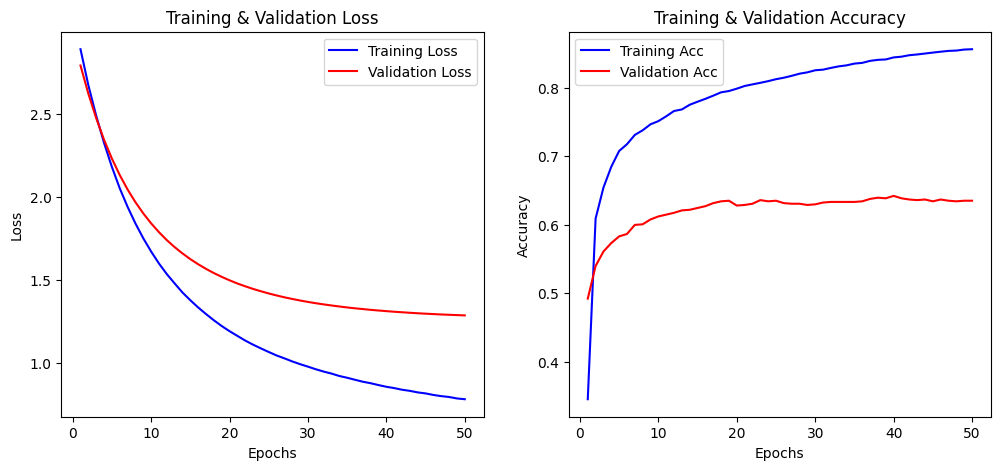

test_loss: 1.4814 and test_accuracy: 0.5709


In [10]:
# In sklearn's Logistic Regression, C is the inverse of regularization strength — a larger C means less regularization. 
# In PyTorch's Adam, weight_decay is the regularization strength directly — a larger value means more regularization. 
# So the they behave oppositely. 
torch.manual_seed(seed)
linear_classifier = LinearModel(X_train_tensor.shape[1], len(target_names))
criterion = nn.CrossEntropyLoss() # this applies softmax activation so you don't need to us nn.Softmax layer
patience = 10
num_epochs = 50
lr = 1e-3
train_classifier = train_test_model(
    device,
    linear_classifier,
    criterion,
    train_loader,
    val_loader,
    patience,
    num_epochs,
    lr,
    l2=1e-5
)
test_loss, test_accuracy = evaluate_model(train_classifier, test_loader, criterion, device)
print(f"test_loss: {test_loss:.4f} and test_accuracy: {test_accuracy:.4f}")

In [11]:
config = {
        "model": LogisticRegression(solver="lbfgs", max_iter=1000, random_state=seed),
        "param_name": "C",
        "values": [0.01, 0.1, 1, 10,100]
    }
tune_sklearn_model(config["model"], 
                   config["param_name"],
                   config["values"],
                   X_train_sparse, y_train, X_test_sparse, y_test)


--- Tuning LogisticRegression (C) ---
C=0.01: Val Acc = 0.4109
C=0.1: Val Acc = 0.5218
C=1: Val Acc = 0.5692
C=10: Val Acc = 0.5478
C=100: Val Acc = 0.5125
🏆 Best C: 1 (Acc: 0.5692)



(1, 0.5691715347849177)

In [12]:
clean_memory()

Memory cleaned.


### One hidden layer Pytorch MLP versus Sklearn Naive Bayes

* concepts:
    - ReLU
    - other activation functions
    - Dropout 

In [13]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
class LinearModel(nn.Module):
    def __init__(self, feature_dim, hidden_dim, output_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_features=feature_dim, out_features=hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(in_features=hidden_dim, out_features=output_dim)
        )
       

    def forward(self, X):
        return self.layers(X)

def check_early_stop(patience, val_loss, model, best_model_state, lowest_loss, counter, epoch):
    early_stop = False
    if val_loss < lowest_loss:
        lowest_loss = val_loss
        best_model_state = deepcopy(model.state_dict())
        counter = 0 
    else:
        counter += 1

    if counter >= patience:
        early_stop = True
    return best_model_state, lowest_loss, counter, early_stop

def get_correct_predictions(logits, y):
    probs = torch.softmax(logits, dim=1)
    preds = torch.argmax(probs, dim=1)
    return (preds == y).float().sum().item()

def evaluate_model(model, data_loader, criterion, device) -> tuple:
    if len(data_loader) <= 0: return 0.0, 0.0
    model.eval()
    total_size = len(data_loader.dataset)
    avg_loss = 0 
    accuracy = 0 
    # eval disables dropout/batchnorm behavior; no_grad saves memory and skips gradient computation
    with torch.no_grad():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            logit = model(x)
            loss = criterion(logit, y)
            avg_loss += loss.item()
            accuracy += get_correct_predictions(logit, y)
    avg_loss/=len(data_loader)
    accuracy/=total_size
    return avg_loss, accuracy

def train_test_model(device, model, criterion, train_loader, val_loader, patience, num_epochs, lr, l2):
    model.to(device)
    optimizer = torch.optim.Adam(params=model.parameters(), lr=lr, weight_decay=l2)
    lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5) 
    best_model_state = deepcopy(model.state_dict())
    lowest_loss = float("inf")
    counter = 0 
    total_train_size = len(train_loader.dataset)
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    for epoch in range(num_epochs):
        model.train()
        avg_train_loss = 0 
        train_accuracy = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logit = model(x)
            loss = criterion(logit, y)
            loss.backward()
            optimizer.step()
            avg_train_loss += loss.item()
            train_accuracy += get_correct_predictions(logit, y)
        avg_train_loss /= len(train_loader)
        train_accuracy /= total_train_size
        train_losses.append(avg_train_loss)
        train_accs.append(train_accuracy)
        avg_val_loss, val_accuracy = evaluate_model(model, val_loader, criterion, device)
        val_losses.append(avg_val_loss)
        val_accs.append(val_accuracy)
        lr_scheduler.step(avg_val_loss)
        best_model_state, lowest_loss, counter, early_stop = check_early_stop(
            patience, avg_val_loss, model, best_model_state, lowest_loss, counter, epoch)
        if epoch % 10 == 0: 
            print(f"Epoch number {epoch} train_loss: {avg_train_loss:.4f} and val_loss: {avg_val_loss:.4f}")
            print(f"Epoch number {epoch} train_accuracy: {train_accuracy:.4f} and val_accuracy: {val_accuracy:.4f}")
        if early_stop:
            print(f"Early stoping with epoch number {epoch}")
            print(f"Train_loss: {avg_train_loss:.4f} and val_loss: {avg_val_loss:.4f}")
            break
    plot_training_history(train_losses, val_losses, train_accs, val_accs)
    model.load_state_dict(best_model_state)
    return model 

Epoch number 0 train_loss: 2.5263 and val_loss: 1.8897
Epoch number 0 train_accuracy: 0.3493 and val_accuracy: 0.5459
Epoch number 10 train_loss: 0.4248 and val_loss: 1.2533
Epoch number 10 train_accuracy: 0.8841 and val_accuracy: 0.6334
Early stoping with epoch number 14
Train_loss: 0.3237 and val_loss: 1.3061


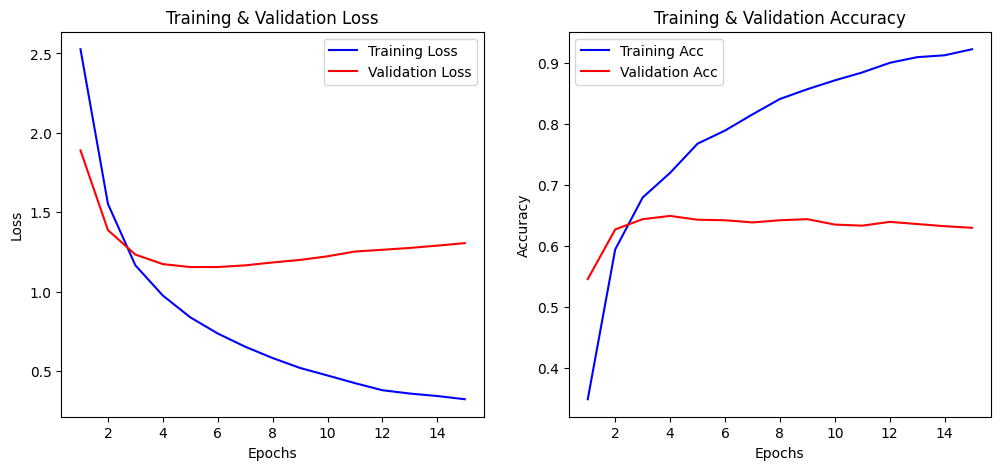

test_loss: 1.3480 and test_accuracy: 0.5858


In [18]:
# In sklearn's Logistic Regression, C is the inverse of regularization strength — a larger C means less regularization. 
# In PyTorch's Adam, weight_decay is the regularization strength directly — a larger value means more regularization. 
# So the they behave oppositely. 
torch.manual_seed(seed)
linear_classifier = LinearModel(X_train_tensor.shape[1], 256, len(target_names))
criterion = nn.CrossEntropyLoss() # this applies softmax activation so you don't need to us nn.Softmax layer
patience = 10
num_epochs = 50
lr = 1e-3
train_classifier = train_test_model(
    device,
    linear_classifier,
    criterion,
    train_loader,
    val_loader,
    patience,
    num_epochs,
    lr,
    l2=1e-5
)
test_loss, test_accuracy = evaluate_model(train_classifier, test_loader, criterion, device)
print(f"test_loss: {test_loss:.4f} and test_accuracy: {test_accuracy:.4f}")

In [17]:
config = {
        "model": MultinomialNB(),
        "param_name": "alpha",
        "values": [0.01, 0.1, 1, 5]
    }
tune_sklearn_model(config["model"], 
                   config["param_name"],
                   config["values"],
                   X_train_sparse, y_train, X_test_sparse, y_test)


--- Tuning MultinomialNB (alpha) ---
alpha=0.01: Val Acc = 0.5730
alpha=0.1: Val Acc = 0.5754
alpha=1: Val Acc = 0.5668
alpha=5: Val Acc = 0.5098
🏆 Best alpha: 0.1 (Acc: 0.5754)



(0.1, 0.5754115772703133)

## Model Performance Analysis

